<a href="https://colab.research.google.com/github/rsys-adsingh/Regression/blob/main/RegressionAlgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective: Predict the median house value for California districts based on 8 features (like median income, house age, and average rooms).

Target Variable ($y$): Median house value (continuous number).

Features ($X$): Housing metrics (Income, Age, Rooms, Population, etc.).

In [11]:
# Import numpy for numerical operations, especially with arrays.
import numpy as np
# Import pandas for data manipulation and analysis, primarily with DataFrames.
import pandas as pd
# Import matplotlib.pyplot for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt
# Import seaborn for high-level data visualization and statistical graphics.
import seaborn as sns

In [12]:
from sklearn.datasets import fetch_california_housing # To load the California housing dataset
from sklearn.model_selection import train_test_split # To split data into training and testing sets
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # For feature scaling and polynomial feature generation
from sklearn.pipeline import Pipeline # To streamline machine learning workflows
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # For evaluating regression model performance

In [13]:
data = fetch_california_housing() # Load the California housing dataset

X = pd.DataFrame(data.data, columns=data.feature_names) # Create a DataFrame for features (X)
y = data.target # Assign the target variable (median house value) to y

In [14]:
print('DataFrame Info:')
X.info()

print('\nFirst 10 rows of the DataFrame:')
display(X.head(10))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB

First 10 rows of the DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


## Data Visualization

# Task
* **Visualize Target Variable Distribution**: Plot a histogram and a Kernel Density Estimate (KDE) plot for the target variable `y` (Median House Value) to understand its distribution, skewness, and potential outliers.
* **Visualize Feature Distributions**: Generate histograms for each feature in the `X` DataFrame to observe their individual distributions, ranges, and patterns. This will help in identifying skewed data or potential data entry errors.
* **Visualize Feature-Target Relationships**: Create scatter plots for each feature in `X` against the target variable `y`. This will help to visually identify any linear or non-linear relationships and assess the influence of each feature on the median house value.
* **Visualize Feature Correlations**: Compute and display a heatmap of the correlation matrix for all features in `X`. This will reveal the strength and direction of linear relationships between pairs of independent variables, which can be useful for feature selection or understanding multicollinearity.
* **Final Task**: Summarize the key insights gained from the data visualizations, highlighting any notable distributions, strong relationships, or significant correlations.

## Pairplot of Features

### Subtask:
Generate a pairplot to visualize pairwise relationships and distributions of all features in the `X` DataFrame. This provides a quick overview of potential correlations and patterns among the independent variables.

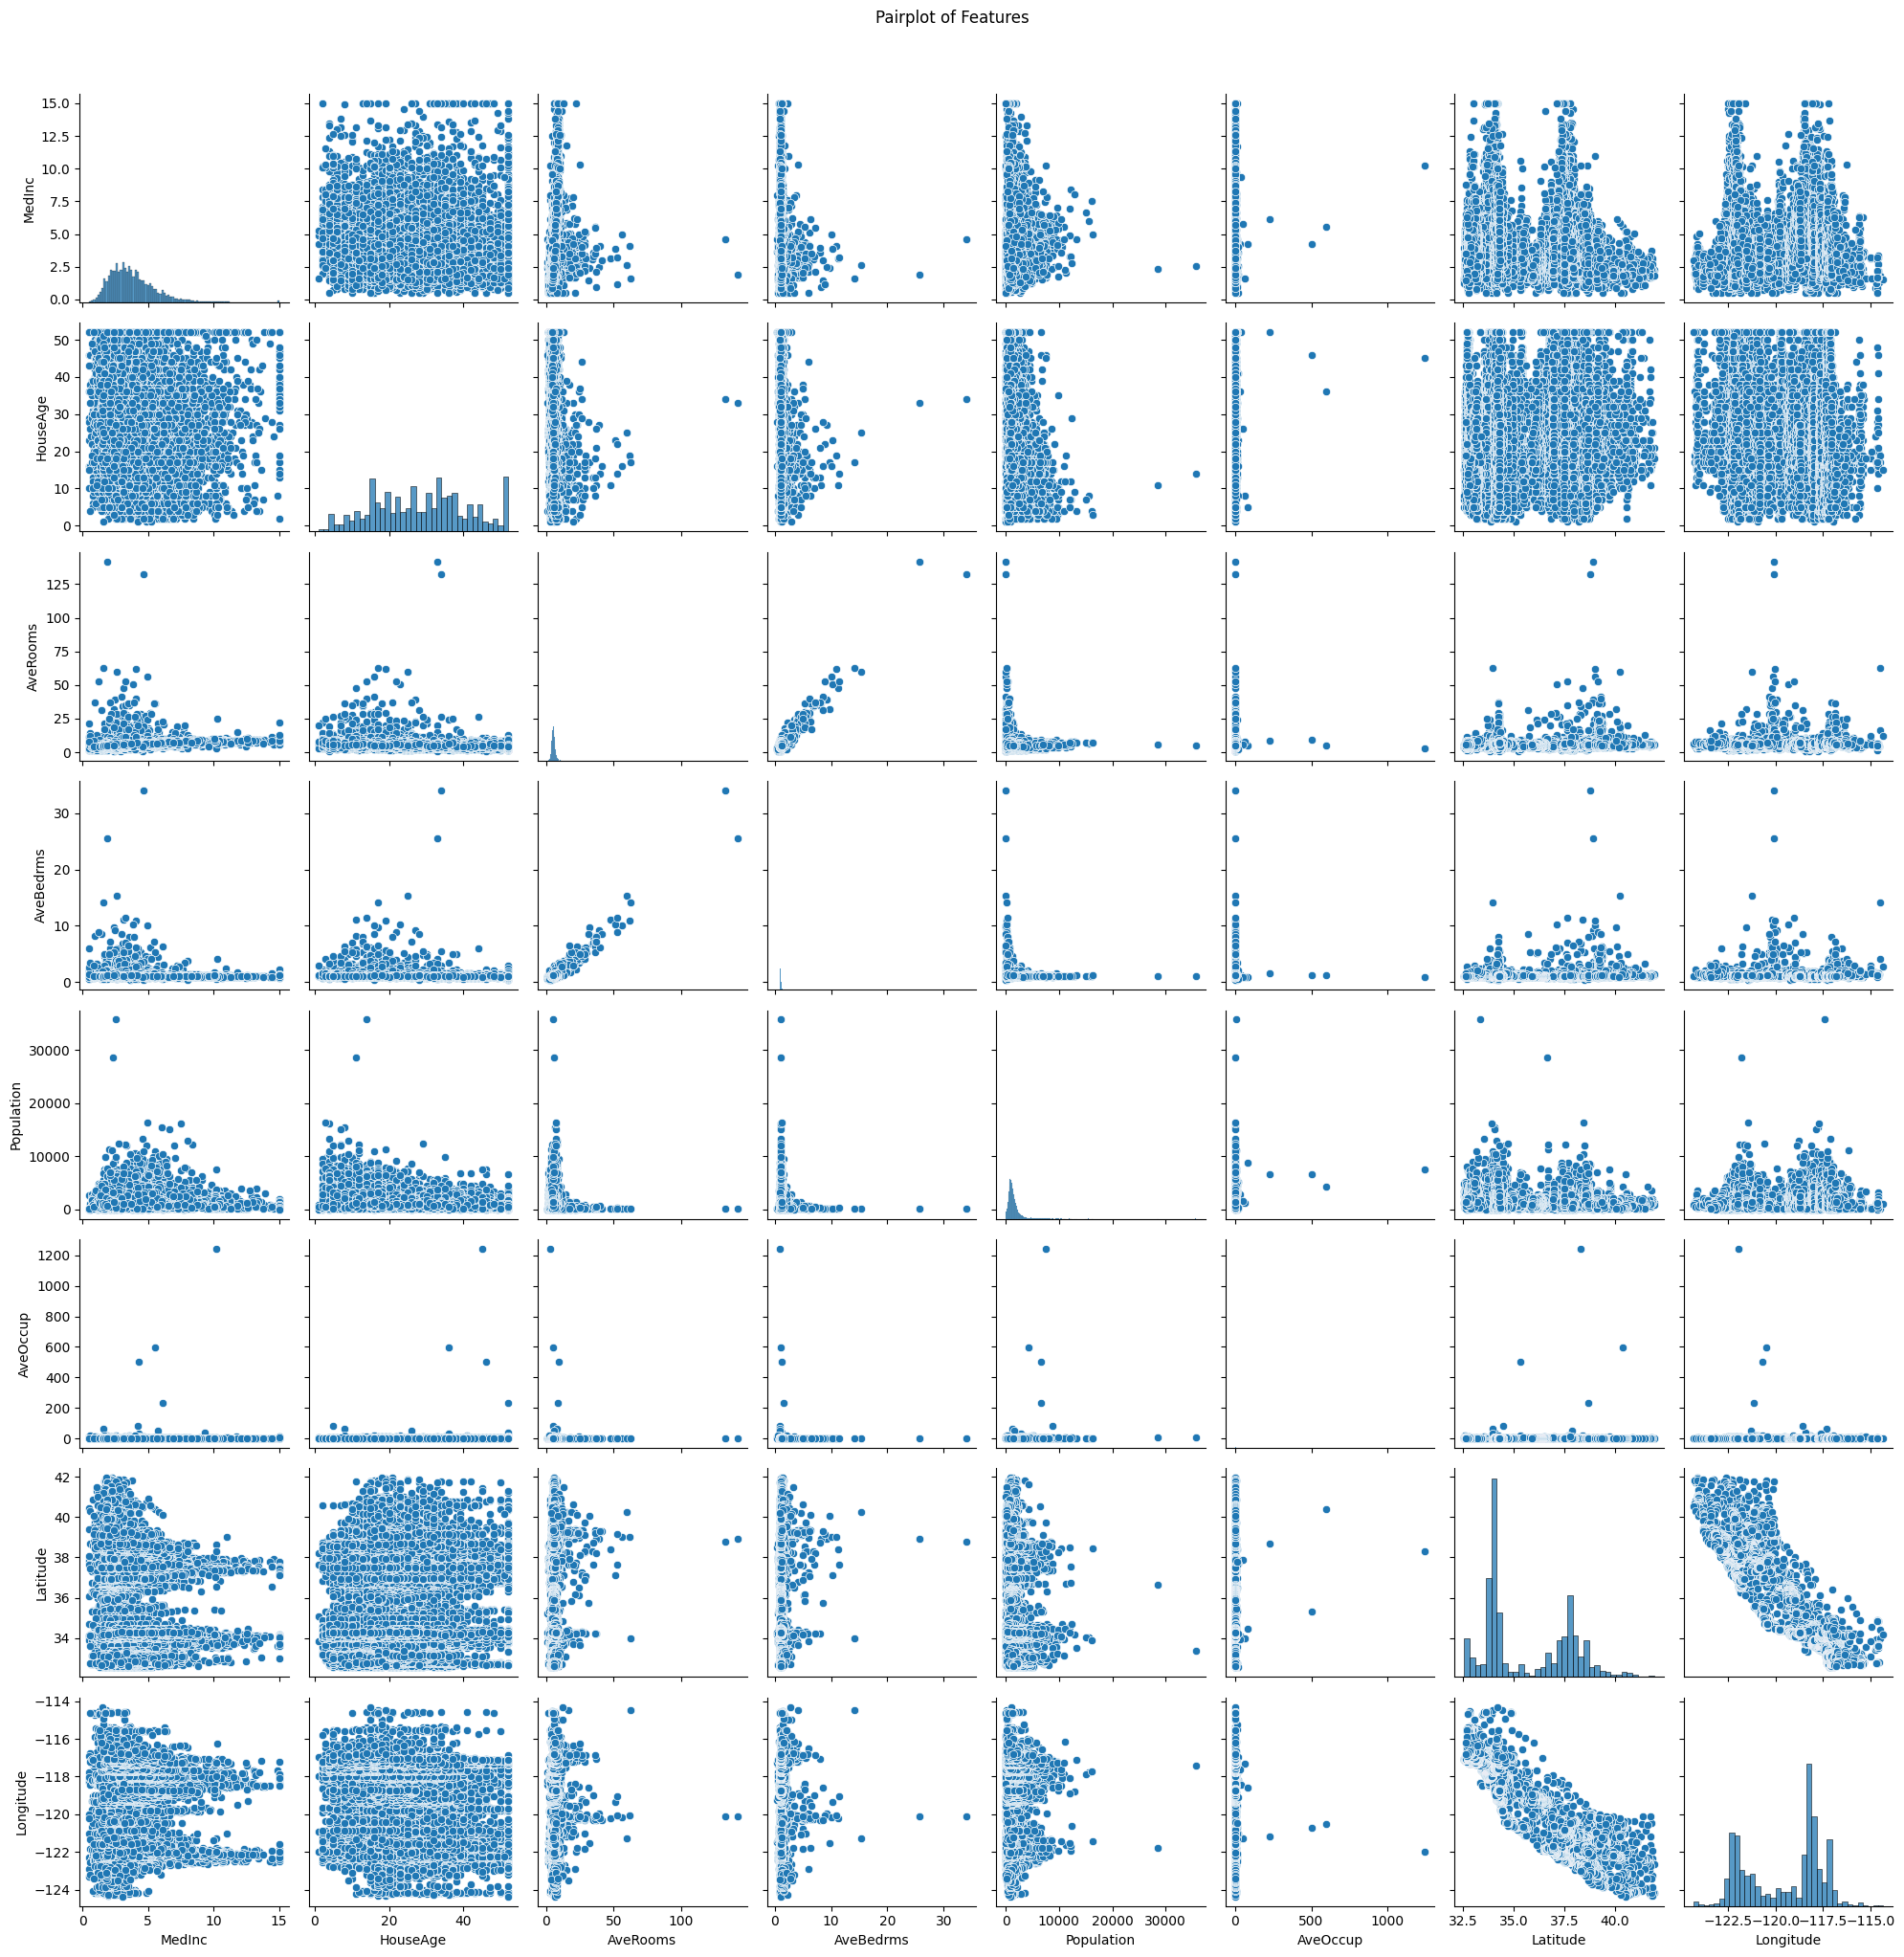

In [15]:
sns.pairplot(X)
plt.suptitle('Pairplot of Features', y=1.02) # Add a title for the entire pairplot
plt.tight_layout()
plt.show()

## Visualize Target Variable Distribution

### Subtask:
Plot a histogram and a Kernel Density Estimate (KDE) plot for the target variable `y` (Median House Value) to understand its distribution, skewness, and potential outliers.


**Reasoning**:
To visualize the distribution, skewness, and potential outliers of the target variable `y`, I will create a histogram with a Kernel Density Estimate (KDE) plot as requested, using seaborn and matplotlib.



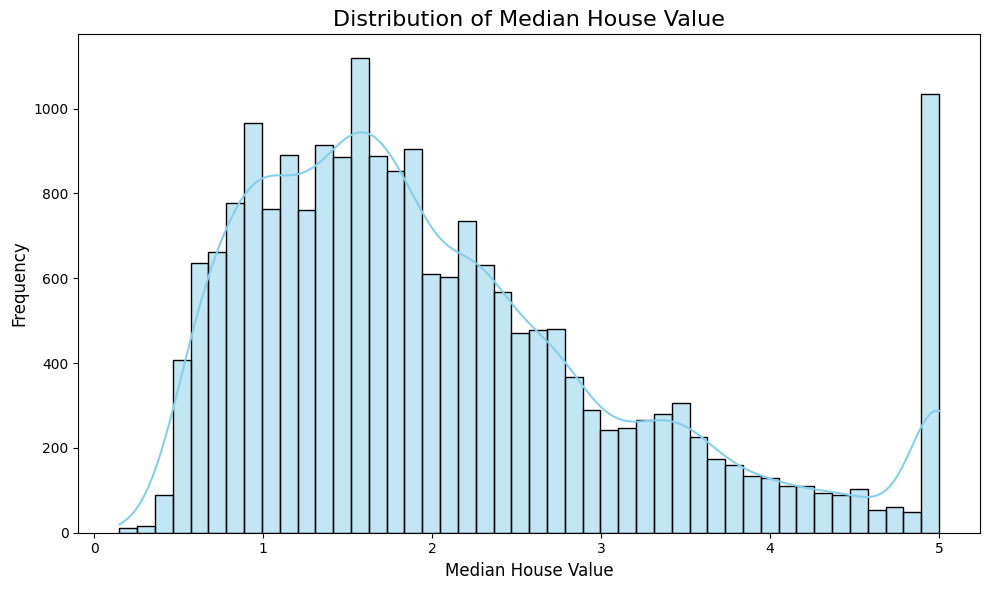

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(y, kde=True, ax=ax, color='skyblue')
ax.set_title('Distribution of Median House Value', fontsize=16)
ax.set_xlabel('Median House Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

## Visualize Feature Distributions

### Subtask:
Generate histograms for each feature in the `X` DataFrame to observe their individual distributions, ranges, and patterns. This will help in identifying skewed data or potential data entry errors.


**Reasoning**:
To visualize the distribution of each feature in the `X` DataFrame, I will generate histograms with KDE plots for each feature, organizing them into subplots for better readability.



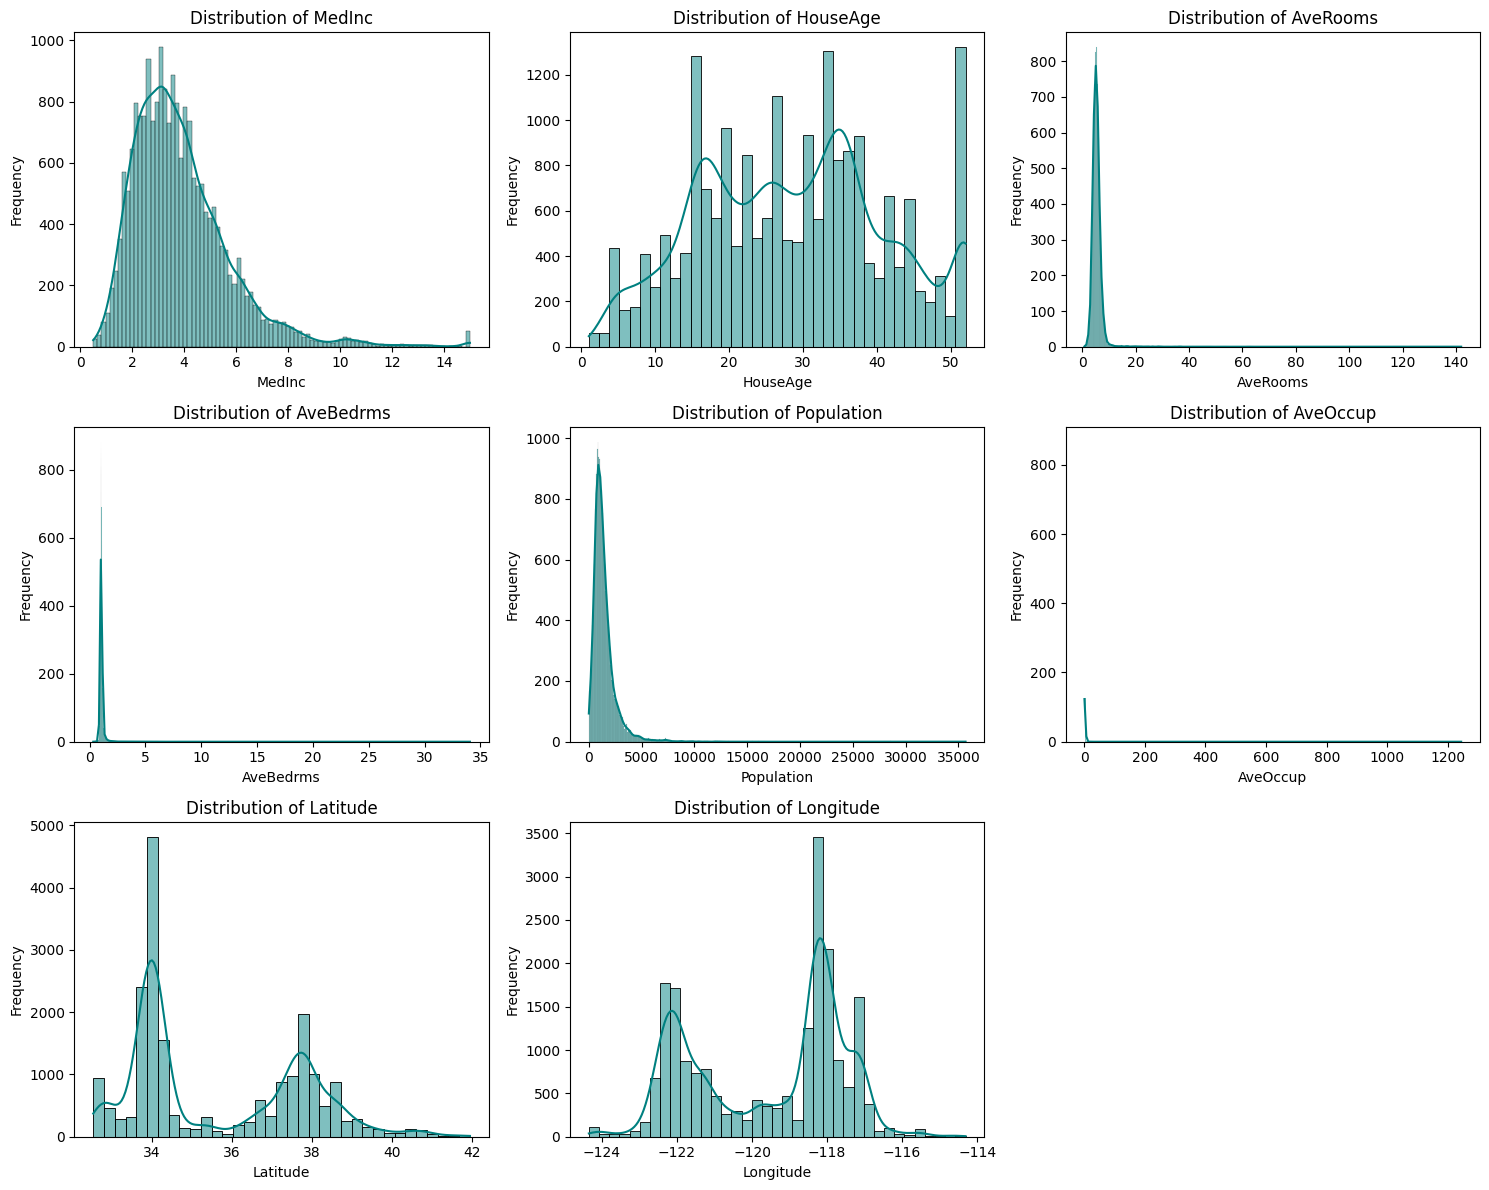

In [17]:
num_features = X.shape[1]
num_cols = 3  # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X.columns):
    sns.histplot(X[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Visualize Feature-Target Relationships

### Subtask:
Create scatter plots for each feature in `X` against the target variable `y`. This will help to visually identify any linear or non-linear relationships and assess the influence of each feature on the median house value.

## Visualize Feature-Target Relationships

### Subtask:
Create scatter plots for each feature in `X` against the target variable `y`. This will help to visually identify any linear or non-linear relationships and assess the influence of each feature on the median house value.

**Reasoning**:
To create scatter plots for each feature against the target variable, I will iterate through each feature in the `X` DataFrame and generate a scatter plot using seaborn's `scatterplot` function, organizing them into subplots.



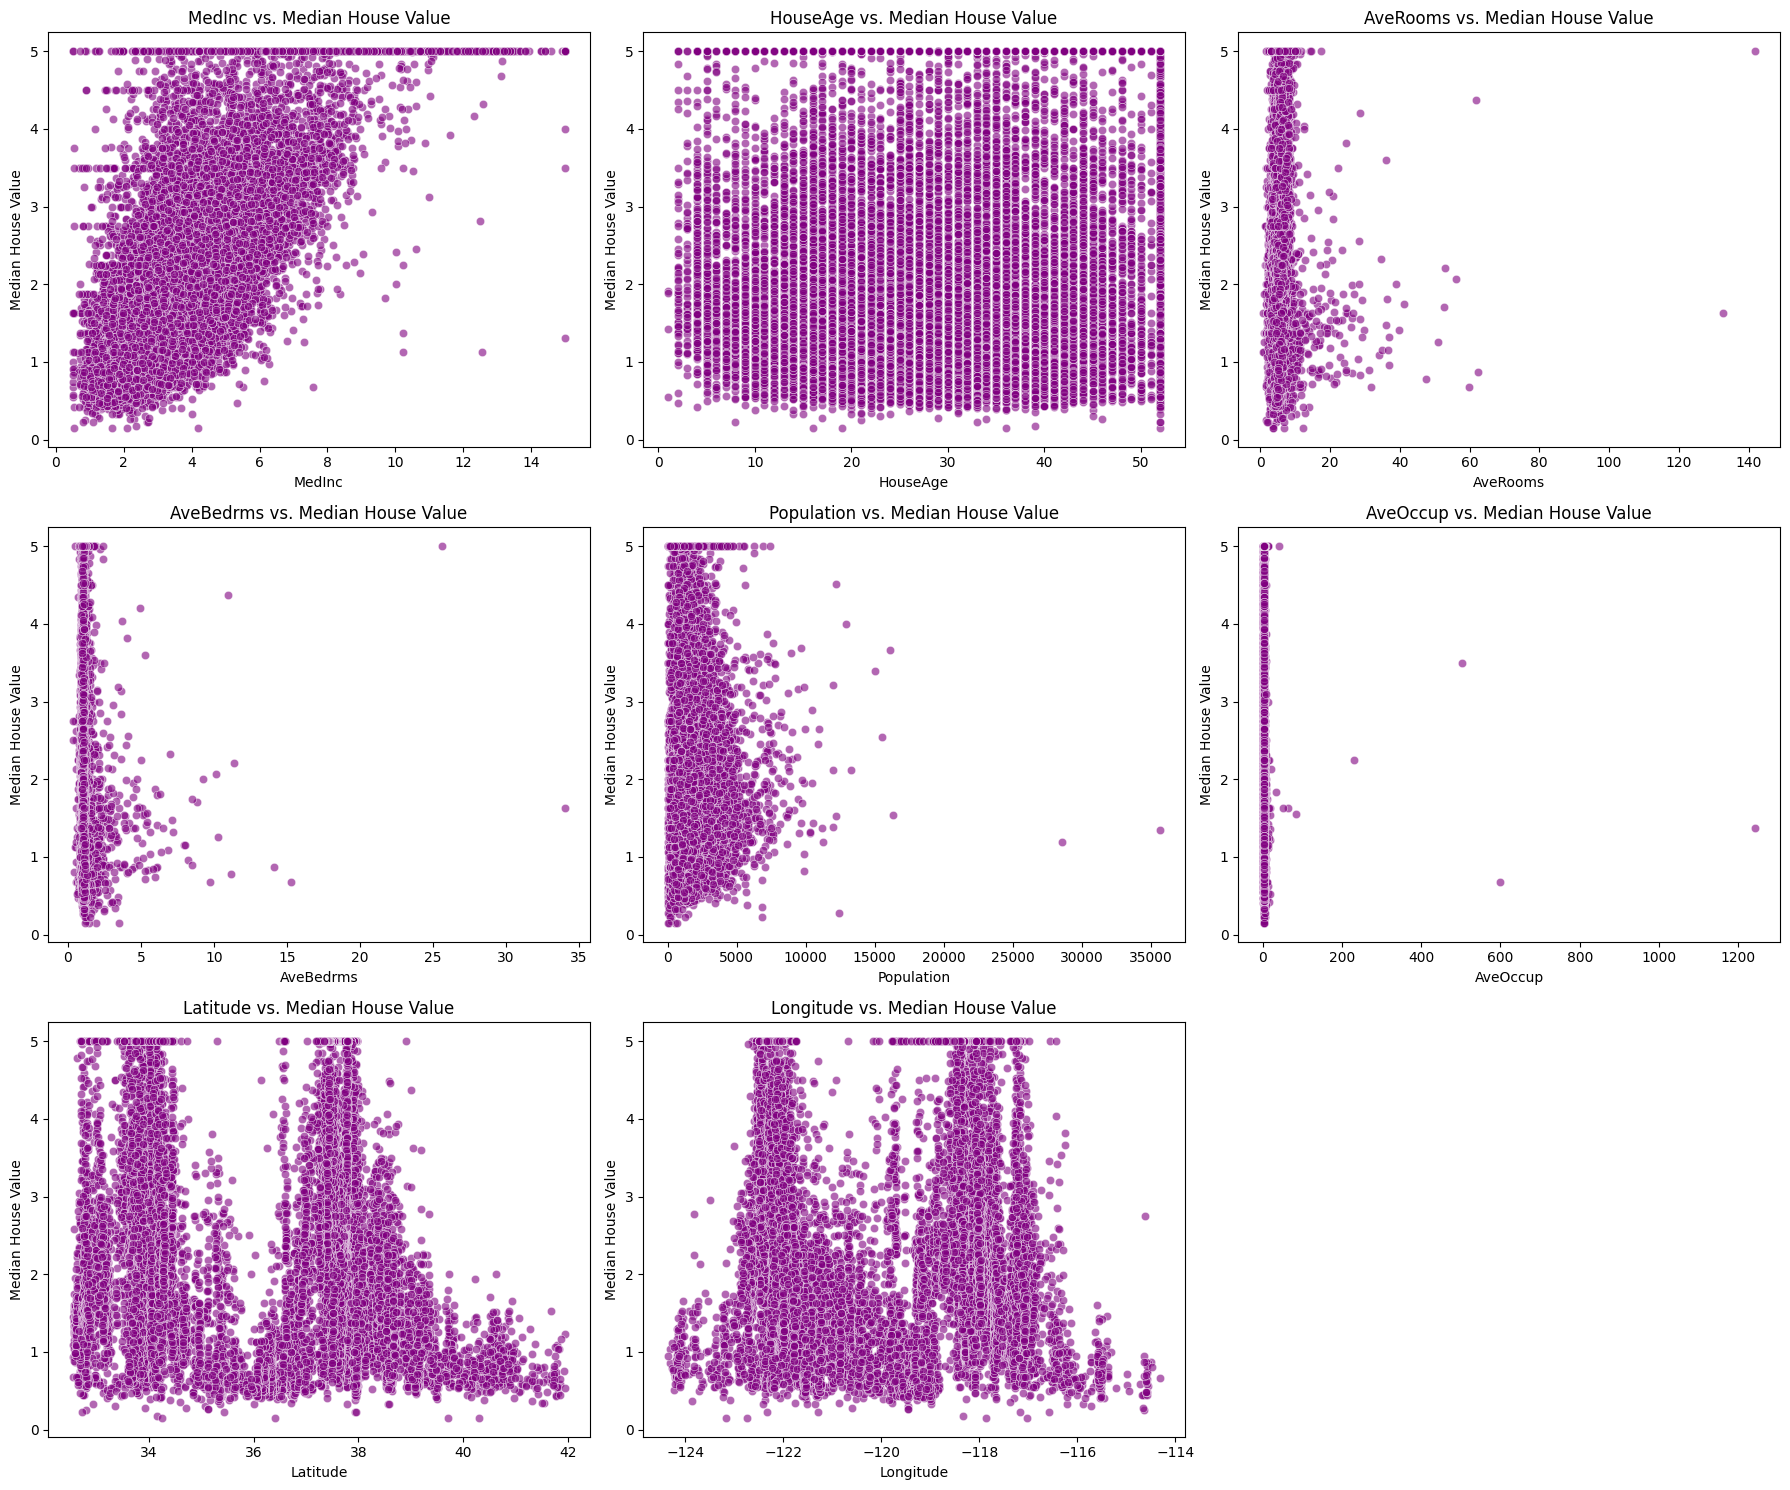

In [18]:
num_features = X.shape[1]
num_cols = 3  # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(X.columns):
    sns.scatterplot(x=X[col], y=y, ax=axes[i], alpha=0.6, color='purple')
    axes[i].set_title(f'{col} vs. Median House Value', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Median House Value', fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Visualize Feature Correlations

### Subtask:
Compute and display a heatmap of the correlation matrix for all features in `X`. This will reveal the strength and direction of linear relationships between pairs of independent variables, which can be useful for feature selection or understanding multicollinearity.

## Visualize Feature Correlations

### Subtask:
Compute and display a heatmap of the correlation matrix for all features in `X`. This will reveal the strength and direction of linear relationships between pairs of independent variables, which can be useful for feature selection or understanding multicollinearity.

**Reasoning**:
To visualize the correlations between all features in the `X` DataFrame, I will first compute the correlation matrix using the `.corr()` method. Then, I will display this matrix as a heatmap using `seaborn.heatmap` to effectively show the strength and direction of linear relationships, which helps in identifying multicollinearity and understanding feature interactions.

**Reasoning**:
To visualize the correlations between all features in the `X` DataFrame, I will first compute the correlation matrix using the `.corr()` method and then display it as a heatmap using `seaborn.heatmap` for clear visual representation, including annotations for better readability.



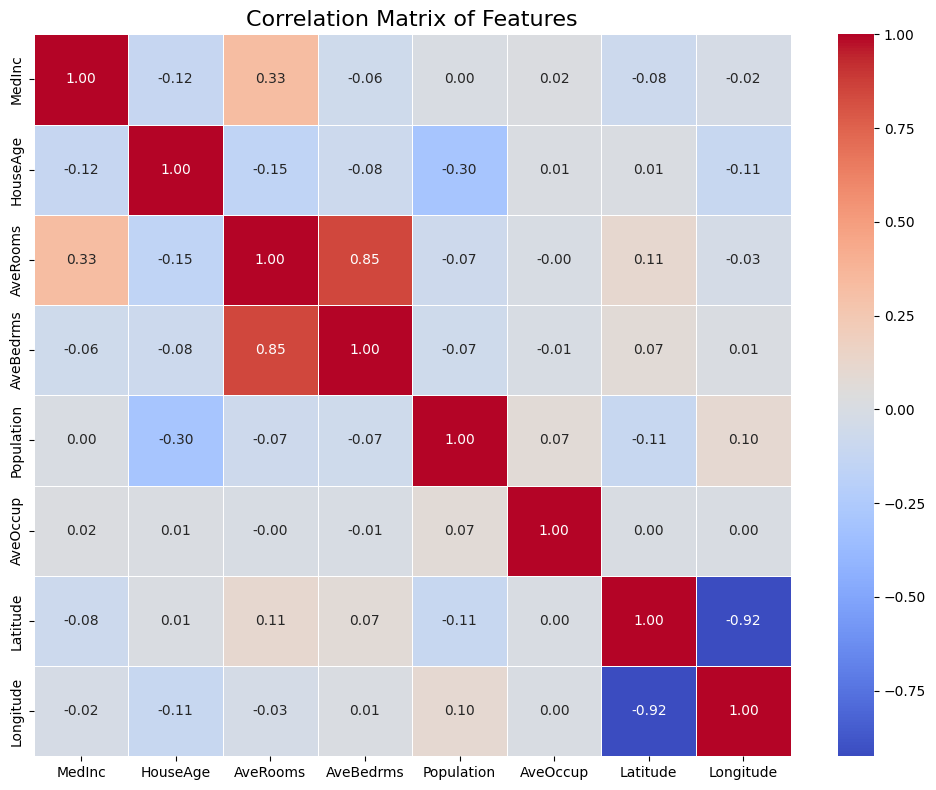

In [19]:
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.tight_layout()
plt.show()

## Summary of Data Visualization Insights

### Notable Distributions:
*   **Target Variable (Median House Value)**: The distribution is right-skewed, indicating that most houses have lower to medium median values, with a smaller number of houses having very high values. There's a noticeable peak around the median and a long tail extending to higher values, suggesting potential outliers or specific high-value areas.
*   **Features in X**: Many features, such as `MedInc` (Median Income) and `Population`, also exhibit right-skewed distributions. This is common in real-world data and might require transformations (e.g., log transformation) for some linear models. `HouseAge` appears more uniformly distributed up to a certain age, then drops off. `AveRooms` and `AveBedrms` show concentrated distributions, likely due to how these values are calculated (averages per household).

### Strong Relationships (Feature-Target):
*   **Median Income (MedInc) vs. Median House Value**: There is a clear positive linear relationship. Higher median income generally corresponds to higher median house values, which is an expected and strong indicator.
*   **Average Occupancy (AveOccup) vs. Median House Value**: This relationship appears to be weak or non-linear, with a wide spread of house values for various occupancy rates.
*   **Latitude and Longitude vs. Median House Value**: These features show spatial patterns. Certain geographical areas (combinations of latitude and longitude) correlate with higher or lower median house values, likely reflecting coastal proximity, city centers, or desirable neighborhoods.

### Significant Correlations (Feature-Feature):
*   **AveRooms and AveBedrms**: There is a very strong positive correlation between the average number of rooms and the average number of bedrooms. This is intuitive, as more rooms often imply more bedrooms. This high correlation suggests potential multicollinearity if both are used directly in a linear model.
*   **MedInc and Latitude/Longitude**: Moderate correlations exist between median income and geographical coordinates, which makes sense as higher-income areas tend to cluster geographically.
*   **HouseAge and Population**: A slight negative correlation, possibly indicating that older neighborhoods might have smaller or more stable populations.

**Overall**: The visualizations confirm that median income is a primary driver of median house value. Geographical location (latitude and longitude) also plays a significant role. Awareness of skewed distributions and multicollinearity (e.g., between `AveRooms` and `AveBedrms`) will be crucial for subsequent data preprocessing and model selection steps.

## Summary:

### Data Analysis Key Findings

*   **Target Variable Distribution**: The Median House Value (`y`) exhibits a right-skewed distribution, indicating a concentration of lower to medium values and a long tail extending towards higher values, suggesting the presence of high-value properties or areas.
*   **Feature Distributions**: Many features, such as `MedInc` (Median Income) and `Population`, also display right-skewed distributions. `HouseAge` shows a more uniform distribution up to a certain point before decreasing. `AveRooms` and `AveBedrms` have concentrated distributions.
*   **Strong Feature-Target Relationships**:
    *   `MedInc` (Median Income) shows a clear and strong positive linear relationship with Median House Value; higher median incomes generally correspond to higher median house values.
    *   `Latitude` and `Longitude` reveal spatial patterns, indicating that specific geographical locations correlate with varying median house values.
    *   `AveOccup` (Average Occupancy) shows a weak or non-linear relationship with Median House Value.
*   **Significant Feature Correlations**:
    *   There is a very strong positive correlation between `AveRooms` and `AveBedrms`, which is intuitive given that more rooms often include more bedrooms.
    *   Moderate correlations exist between `MedInc` and geographical coordinates (`Latitude`/`Longitude`), reflecting that higher-income areas tend to be geographically clustered.
    *   A slight negative correlation was observed between `HouseAge` and `Population`.

### Insights or Next Steps

*   The prominent right-skewness observed in the target variable and several features suggests that data transformations (e.g., log transformation) might be beneficial for certain models, particularly linear ones, to meet their assumptions.
*   The strong correlation between `AveRooms` and `AveBedrms` indicates potential multicollinearity. Consideration should be given to addressing this, perhaps by selecting one of the features or combining them, during feature engineering to improve model stability and interpretability.


## **Feature Engineering & Data Pre-processing**

# Task
Perform feature engineering and data preprocessing by adding a markdown section titled 'Feature Engineering & Data Pre-processing', log transforming the skewed target variable `y`, log transforming skewed features such as 'MedInc', 'Population', 'AveRooms', and 'AveBedrms' in `X`, standard scaling all features in `X` using `StandardScaler`, and finally splitting the processed data into training and testing sets.

## Log Transform Skewed Target Variable

### Subtask:
Apply a log transformation to the target variable `y` to reduce its right-skewness, as observed in the distribution plot. This helps stabilize variance and make the distribution more Gaussian-like, which is beneficial for many regression models.


**Reasoning**:
To apply the log transformation as instructed, I will use `np.log1p()` on the target variable `y` and then print the first few values to verify the transformation.



In [20]:
y = np.log1p(y)
print('First 5 values of log-transformed y:')
print(y[:5])

First 5 values of log-transformed y:
[1.70946423 1.52279011 1.50873321 1.48455473 1.48659208]


## Log Transform Skewed Features

### Subtask:
Identify and apply a log transformation to features in `X` that exhibit significant right-skewness (e.g., 'MedInc', 'Population', 'AveRooms', and 'AveBedrms' based on earlier histograms) to normalize their distributions. This can improve model performance by meeting assumptions of linearity for certain algorithms.


**Reasoning**:
To apply the log transformation to the identified skewed features, I will iterate through the list of specified columns and apply `np.log1p()` to each within the `X` DataFrame. Afterward, I will display the first few rows of the modified `X` DataFrame to confirm the transformation.



In [21]:
skewed_features = ['MedInc', 'Population', 'AveRooms', 'AveBedrms']

for feature in skewed_features:
    X[feature] = np.log1p(X[feature])

print('First 5 rows of X with log-transformed skewed features:')
display(X.head())

First 5 rows of X with log-transformed skewed features:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.232720,41.0,2.077455,0.704982,5.777652,2.555556,37.88,-122.23
1,2.230165,21.0,1.979364,0.678988,7.784057,2.109842,37.86,-122.22
2,2.111110,52.0,2.228738,0.729212,6.208590,2.802260,37.85,-122.24
3,1.893579,52.0,1.919471,0.729025,6.326149,2.547945,37.85,-122.25
4,1.578195,52.0,1.985385,0.732888,6.338594,2.181467,37.85,-122.25


## Standard Scale Features

### Subtask:
Standard scale all features in the `X` DataFrame using `StandardScaler` to normalize their ranges. This is crucial for many machine learning algorithms that are sensitive to the scale of input features, ensuring that no single feature dominates the learning process due to its larger values.

**Reasoning**:
To perform standard scaling on the features in `X`, I will initialize a `StandardScaler` and then apply it to the `X` DataFrame. I will then display the first 5 rows of the scaled data to verify the transformation.



In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('First 5 rows of X after standard scaling:')
display(X_scaled_df.head())

First 5 rows of X after standard scaling:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.995505,0.982143,1.072436,-0.256650,-1.694943,-0.049597,1.052548,-1.327835
1,1.988380,-0.607019,0.649505,-0.503251,1.030337,-0.092512,1.043185,-1.322844
2,1.656444,1.856182,1.724704,-0.026779,-1.109604,-0.025843,1.038503,-1.332827
3,1.049948,1.856182,0.391271,-0.028550,-0.949925,-0.050329,1.038503,-1.337818
4,0.170631,1.856182,0.675467,0.008089,-0.933021,-0.085616,1.038503,-1.337818


## Split Data into Training and Testing Sets

### Subtask:
Split the processed `X_scaled_df` and `y` into training and testing sets using `train_test_split`. This step is crucial for evaluating the model's performance on unseen data and preventing overfitting. The split should be 80% for training and 20% for testing, with a `random_state` for reproducibility.

## Split Data into Training and Testing Sets

### Subtask:
Split the processed `X_scaled_df` and `y` into training and testing sets using `train_test_split`. This step is crucial for evaluating the model's performance on unseen data and preventing overfitting. The split should be 80% for training and 20% for testing, with a `random_state` for reproducibility.

**Reasoning**:
To split the processed data into training and testing sets, I will use `train_test_split` from `sklearn.model_selection` with a test size of 0.2 (20%) and a specified `random_state` for reproducibility. After splitting, I'll print the shapes of the resulting datasets to confirm the split.



In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (16512, 8)
Shape of X_test: (4128, 8)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


## Summary:

### Q&A
The feature engineering and data preprocessing steps involved:
1.  **Log Transformation of the Target Variable (`y`):** The target variable `y` was log-transformed using `np.log1p()` to reduce its right-skewness, stabilize variance, and make its distribution more Gaussian-like, which is beneficial for many regression models.
2.  **Log Transformation of Skewed Features (`X`):** Features identified as right-skewed ('MedInc', 'Population', 'AveRooms', 'AveBedrms') were log-transformed using `np.log1p()`. This normalizes their distributions, potentially improving model performance by better meeting assumptions of linearity for certain algorithms.
3.  **Standard Scaling of Features (`X`):** All features in the `X` DataFrame were scaled using `StandardScaler`. This normalizes their ranges, which is crucial for machine learning algorithms sensitive to input feature scales, preventing features with larger values from dominating the learning process.
4.  **Splitting Data into Training and Testing Sets:** The processed `X` and `y` data were split into training and testing sets (80% for training, 20% for testing) using `train_test_split` with a `random_state=42`. This step is essential for evaluating the model's performance on unseen data and preventing overfitting.

### Data Analysis Key Findings
*   The target variable `y` was successfully log-transformed, with the first five values changing to approximately \[1.709, 1.523, 1.509, 1.485, 1.487].
*   Skewed features ('MedInc', 'Population', 'AveRooms', 'AveBedrms') in `X` were log-transformed using `np.log1p()`, confirming the transformation in the `X.head()` output.
*   All features in `X` were standard scaled using `StandardScaler`, creating a new DataFrame `X_scaled_df` with normalized values.
*   The processed data was split into:
    *   `X_train` with shape (16512, 8)
    *   `X_test` with shape (4128, 8)
    *   `y_train` with shape (16512,)
    *   `y_test` with shape (4128,)

### Insights or Next Steps
*   The data is now thoroughly preprocessed and prepared for robust model training and evaluation.
*   The transformations applied are expected to improve model performance, stability, and adherence to algorithm assumptions.
